the dataset dont contain pre made rows and columns , so we are creating newly.. the 1st column will be engine id , 2nd is cycle , then next 3 are settings , and then next 21 will be the censors


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Column names (dataset has no header row)
columns = ['engine_id', 'cycle'] + \
          [f'setting_{i}' for i in range(1,4)] + \
          [f'sensor_{i}' for i in range(1,22)]

# Load the data
# Make sure 'train_FD001.txt' is uploaded to the Colab environment's root,
# or update the path if it's in Google Drive (e.g., '/content/drive/MyDrive/path/to/train_FD001.txt')
df = pd.read_csv('/content/train_FD001.txt', sep=r'\s+', header=None, names=columns)

print(df.shape)
print(df.isnull().sum().sum())
df.head()

(20631, 26)
0


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


Total engines: 100
Shortest life: 128 cycles
Longest life: 362 cycles
Average life: 206 cycles


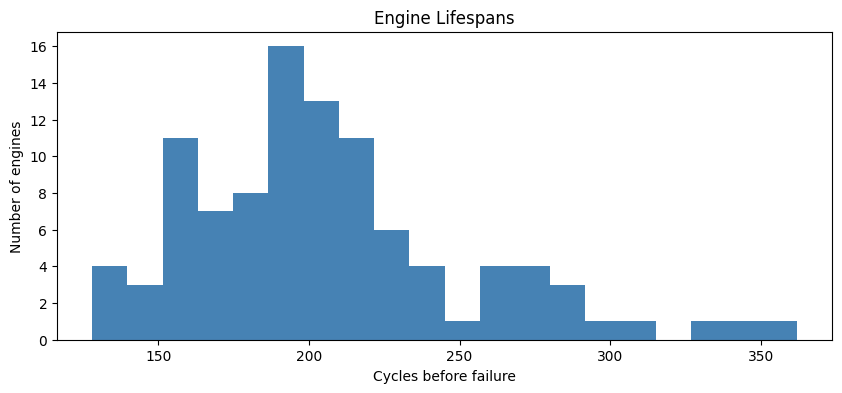

In [ ]:
# How many unique engines, and how many cycles each one survived
engine_cycles = df.groupby('engine_id')['cycle'].max()

print(f"Total engines: {engine_cycles.count()}")
print(f"Shortest life: {engine_cycles.min()} cycles")
print(f"Longest life: {engine_cycles.max()} cycles")
print(f"Average life: {engine_cycles.mean():.0f} cycles")

# Visualize it
engine_cycles.plot(kind='hist', bins=20, figsize=(10,4), color='steelblue')
plt.title('Engine Lifespans')
plt.xlabel('Cycles before failure')
plt.ylabel('Number of engines')
plt.show()

In [ ]:
# Calculate RUL for every row
max_cycles = df.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.columns = ['engine_id', 'max_cycle']

df = df.merge(max_cycles, on='engine_id')
df['RUL'] = df['max_cycle'] - df['cycle']

# Cap RUL at 125
df['RUL'] = df['RUL'].clip(upper=125)

# Drop max_cycle column, we don't need it anymore
df.drop(columns=['max_cycle'], inplace=True)

print(df[['engine_id', 'cycle', 'RUL']].head(10))

   engine_id  cycle  RUL
0          1      1  125
1          1      2  125
2          1      3  125
3          1      4  125
4          1      5  125
5          1      6  125
6          1      7  125
7          1      8  125
8          1      9  125
9          1     10  125


In [ ]:
# Find sensors with only 1 unique value (constant = useless)
constant_sensors = [col for col in df.columns
                    if col.startswith('sensor')
                    and df[col].nunique() <= 1]

print("Dropping:", constant_sensors)
df.drop(columns=constant_sensors, inplace=True)
print(f"Columns remaining: {df.shape[1]}")

Dropping: ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Columns remaining: 20


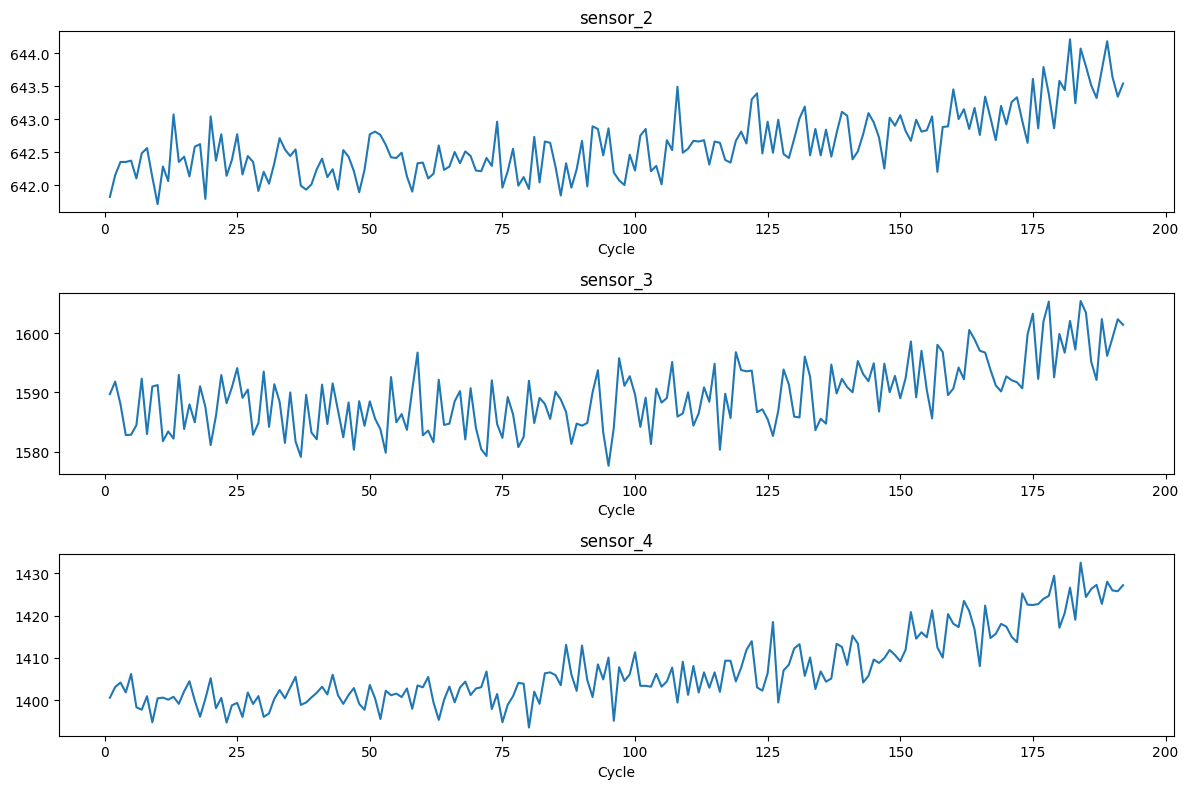

In [ ]:
# Pick one engine and plot how sensors change over time
engine_1 = df[df['engine_id'] == 1]

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

for i, sensor in enumerate(['sensor_2', 'sensor_3', 'sensor_4']):
    axes[i].plot(engine_1['cycle'], engine_1[sensor])
    axes[i].set_title(sensor)
    axes[i].set_xlabel('Cycle')

plt.tight_layout()
plt.show()

In [ ]:
# Create degradation stage based on RUL
def assign_stage(rul):
    if rul > 100:
        return 0  # Healthy
    elif rul > 30:
        return 1  # Warning
    else:
        return 2  # Critical

df['stage'] = df['RUL'].apply(assign_stage)

print(df['stage'].value_counts())


stage
0    10531
1     7000
2     3100
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Identify sensor columns only
sensor_cols = [col for col in df.columns if col.startswith('sensor')]

# Scale sensors to 0-1 range
scaler = MinMaxScaler()
df[sensor_cols] = scaler.fit_transform(df[sensor_cols])

df[sensor_cols].describe().round(2)

,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
count,20631.00,20631.00,20631.00,20631.00,20631.00,20631.00,20631.00,20631.00,20631.00,20631.00,20631.00,20631.00,20631.00,20631.00,20631.00
mean,0.44,0.42,0.45,0.98,0.57,0.30,0.20,0.41,0.58,0.32,0.23,0.45,0.43,0.52,0.55
std,0.15,0.13,0.15,0.14,0.14,0.11,0.10,0.16,0.16,0.11,0.10,0.14,0.13,0.14,0.15
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.34,0.33,0.34,1.00,0.48,0.23,0.14,0.30,0.48,0.24,0.17,0.35,0.33,0.43,0.45
50%,0.43,0.42,0.44,1.00,0.58,0.29,0.17,0.39,0.59,0.31,0.21,0.44,0.42,0.53,0.56
75%,0.54,0.51,0.55,1.00,0.67,0.36,0.21,0.51,0.70,0.38,0.25,0.54,0.50,0.63,0.65
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [ ]:
import joblib

# Save scaler for use in the API later
joblib.dump(scaler, 'scaler.pkl')
print("Scaler saved.")

Scaler saved.


In [ ]:
from google.colab import files
files.download('scaler.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

in this next code , we create 3 lists , each to store different type of data
And before that we separate out each engine's data into a temporary separate dataframe wo that during appending input data of each engine inside X , the data from different engines dont get mixed in our 30 engines input window for our lstm.



X is the list which will contain the input for the lstm -> all

In [ ]:
import numpy as np

def create_sequences(df, sequence_length=30):
    X, y_rul, y_stage = [], [], []

    # For each engine, create sliding windows
    for engine_id in df['engine_id'].unique():
        engine_df = df[df['engine_id'] == engine_id]
        sensors = engine_df[sensor_cols].values
        rul = engine_df['RUL'].values
        stage = engine_df['stage'].values

        # Slide a window of 30 cycles across the engine's life
        for i in range(len(engine_df) - sequence_length):
            X.append(sensors[i:i+sequence_length])
            y_rul.append(rul[i+sequence_length])
            y_stage.append(stage[i+sequence_length])

    return np.array(X), np.array(y_rul), np.array(y_stage)

X, y_rul, y_stage = create_sequences(df)
print(f"X shape: {X.shape}")
print(f"y_rul shape: {y_rul.shape}")

X shape: (17631, 30, 15)
y_rul shape: (17631,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_rul_train, y_rul_test, y_stage_train, y_stage_test = \
    train_test_split(X, y_rul, y_stage, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 14104
Testing samples: 3527


In [ ]:
import torch
import torch.nn as nn

# Build the LSTM model
class EngineRUL(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=15, hidden_size=64,
                           num_layers=2, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model = EngineRUL()
print(model)

EngineRUL(
  (lstm): LSTM(15, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [ ]:
from torch.utils.data import DataLoader, TensorDataset

# Convert data to PyTorch tensors
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_rul_train)

# Package into DataLoader (feeds data in batches)
dataset = TensorDataset(X_train_t, y_train_t)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

# Setup training
criterion = nn.MSELoss()
"""optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Train for 20 epochs
for epoch in range(20):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        pred = model(X_batch).squeeze()
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/20 — Loss: {total_loss/len(loader):.4f}")"""

'optimizer = torch.optim.Adam(model.parameters(), lr=0.001)\n\n# Train for 20 epochs\nfor epoch in range(20):\n    model.train()\n    total_loss = 0\n    for X_batch, y_batch in loader:\n        optimizer.zero_grad()\n        pred = model(X_batch).squeeze()\n        loss = criterion(pred, y_batch)\n        loss.backward()\n        optimizer.step()\n        total_loss += loss.item()\n\n    if (epoch+1) % 5 == 0:\n        print(f"Epoch {epoch+1}/20 — Loss: {total_loss/len(loader):.4f}")'

In [ ]:
"""model.eval()
X_test_t = torch.FloatTensor(X_test)

with torch.no_grad():
    predictions = model(X_test_t).squeeze().numpy()

# RMSE = average error in cycles
rmse = np.sqrt(np.mean((predictions - y_rul_test)**2))
print(f"RMSE: {rmse:.2f} cycles")

# Plot predicted vs actual
plt.figure(figsize=(12,4))
plt.plot(y_rul_test[:200], label='Actual RUL')
plt.plot(predictions[:200], label='Predicted RUL')
plt.legend()
plt.title('Predicted vs Actual RUL')
plt.xlabel('Sample')
plt.ylabel('RUL')
plt.show()"""

'model.eval()\nX_test_t = torch.FloatTensor(X_test)\n\nwith torch.no_grad():\n    predictions = model(X_test_t).squeeze().numpy()\n\n# RMSE = average error in cycles\nrmse = np.sqrt(np.mean((predictions - y_rul_test)**2))\nprint(f"RMSE: {rmse:.2f} cycles")\n\n# Plot predicted vs actual\nplt.figure(figsize=(12,4))\nplt.plot(y_rul_test[:200], label=\'Actual RUL\')\nplt.plot(predictions[:200], label=\'Predicted RUL\')\nplt.legend()\nplt.title(\'Predicted vs Actual RUL\')\nplt.xlabel(\'Sample\')\nplt.ylabel(\'RUL\')\nplt.show()'

In [ ]:
"""# Reset and retrain with 50 epochs

model_01 = EngineRUL()
optimizer = torch.optim.Adam(model_01.parameters(), lr=0.001)

for epoch in range(60):
    model_01.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        pred = model_01(X_batch).squeeze()
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/50 — Loss: {total_loss/len(loader):.4f}")"""

'# Reset and retrain with 50 epochs\n\nmodel_01 = EngineRUL()\noptimizer = torch.optim.Adam(model_01.parameters(), lr=0.001)\n\nfor epoch in range(60):\n    model_01.train()\n    total_loss = 0\n    for X_batch, y_batch in loader:\n        optimizer.zero_grad()\n        pred = model_01(X_batch).squeeze()\n        loss = criterion(pred, y_batch)\n        loss.backward()\n        optimizer.step()\n        total_loss += loss.item()\n\n    if (epoch+1) % 10 == 0:\n        print(f"Epoch {epoch+1}/50 — Loss: {total_loss/len(loader):.4f}")'

In [ ]:
"""model_01.eval()
with torch.no_grad():
    predictions = model_01(X_test_t).squeeze().numpy()

rmse = np.sqrt(np.mean((predictions - y_rul_test)**2))
print(f"RMSE: {rmse:.2f} cycles")

plt.figure(figsize=(12,4))
plt.plot(y_rul_test[:200], label='Actual RUL')
plt.plot(predictions[:200], label='Predicted RUL')
plt.legend()
plt.title('Predicted vs Actual RUL')
plt.xlabel('Sample')
plt.ylabel('RUL')
plt.show()"""

'model_01.eval()\nwith torch.no_grad():\n    predictions = model_01(X_test_t).squeeze().numpy()\n\nrmse = np.sqrt(np.mean((predictions - y_rul_test)**2))\nprint(f"RMSE: {rmse:.2f} cycles")\n\nplt.figure(figsize=(12,4))\nplt.plot(y_rul_test[:200], label=\'Actual RUL\')\nplt.plot(predictions[:200], label=\'Predicted RUL\')\nplt.legend()\nplt.title(\'Predicted vs Actual RUL\')\nplt.xlabel(\'Sample\')\nplt.ylabel(\'RUL\')\nplt.show()'

In [ ]:
"""# Reset and retrain with 80 epochs

model_02 = EngineRUL()
optimizer = torch.optim.Adam(model_02.parameters(), lr=0.001)

for epoch in range(300):
    model_02.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        pred = model_02(X_batch).squeeze()
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/300 — Loss: {total_loss/len(loader):.4f}")"""

KeyboardInterrupt: 

In [ ]:
# Reset and retrain with 350 epochs

model_03 = EngineRUL()
optimizer = torch.optim.Adam(model_03.parameters(), lr=0.001)

for epoch in range(300):
    model_03.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        pred = model_03(X_batch).squeeze()
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/350 — Loss: {total_loss/len(loader):.4f}")

Epoch 10/350 — Loss: 1751.4114
Epoch 20/350 — Loss: 1744.4132
Epoch 30/350 — Loss: 1744.2452
Epoch 40/350 — Loss: 189.5051
Epoch 50/350 — Loss: 175.0249
Epoch 60/350 — Loss: 164.9422
Epoch 70/350 — Loss: 160.8020
Epoch 80/350 — Loss: 153.8321
Epoch 90/350 — Loss: 147.1526
Epoch 100/350 — Loss: 141.9089
Epoch 110/350 — Loss: 131.4286
Epoch 120/350 — Loss: 118.4276
Epoch 130/350 — Loss: 104.8534
Epoch 140/350 — Loss: 99.6903
Epoch 150/350 — Loss: 86.4235
Epoch 160/350 — Loss: 82.2511
Epoch 170/350 — Loss: 71.9879
Epoch 180/350 — Loss: 59.2344
Epoch 190/350 — Loss: 52.7237
Epoch 200/350 — Loss: 45.9503
Epoch 210/350 — Loss: 39.7006
Epoch 220/350 — Loss: 32.5156
Epoch 230/350 — Loss: 31.0249
Epoch 240/350 — Loss: 25.6336
Epoch 250/350 — Loss: 22.0648
Epoch 260/350 — Loss: 24.6634
Epoch 270/350 — Loss: 15.0498
Epoch 280/350 — Loss: 13.9610
Epoch 290/350 — Loss: 12.2206
Epoch 300/350 — Loss: 13.0795


RMSE: 3.70 cycles


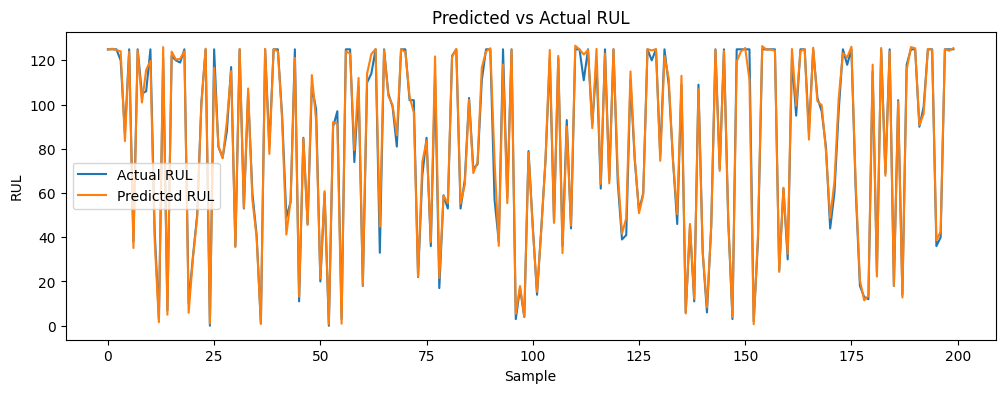

In [ ]:
model_03.eval()
X_test_t = torch.FloatTensor(X_test)
with torch.no_grad():
    predictions = model_03(X_test_t).squeeze().numpy()

rmse = np.sqrt(np.mean((predictions - y_rul_test)**2))
print(f"RMSE: {rmse:.2f} cycles")

plt.figure(figsize=(12,4))
plt.plot(y_rul_test[:200], label='Actual RUL')
plt.plot(predictions[:200], label='Predicted RUL')
plt.legend()
plt.title('Predicted vs Actual RUL')
plt.xlabel('Sample')
plt.ylabel('RUL')
plt.show()














In [ ]:
torch.save(model_03.state_dict(), 'rul_model.pth')
print("Model saved.")

Model saved.


In [ ]:
print(model_03)

EngineRUL(
  (lstm): LSTM(15, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


**ANOMALY DETECTION **

In [ ]:
# Only keep cycles where RUL > 125 (healthy engines)
healthy_df = df[df['RUL'] == 125]

print(f"Healthy rows: {len(healthy_df)}")
print(f"Total rows: {len(df)}")

Healthy rows: 8131
Total rows: 20631


In [ ]:
# Get just the sensor readings from healthy data
healthy_sensors = healthy_df[sensor_cols].values

# Convert to PyTorch tensor
healthy_t = torch.FloatTensor(healthy_sensors)

# DataLoader for training
healthy_dataset = TensorDataset(healthy_t, healthy_t)
healthy_loader = DataLoader(healthy_dataset, batch_size=64, shuffle=True)

print(f"Healthy data shape: {healthy_sensors.shape}")

# Notice TensorDataset(healthy_t, healthy_t) — input and output are the same thing. The Autoencoder's job is to recreate its own input perfectly.

Healthy data shape: (8131, 15)


In [ ]:
class EngineAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder — squeezes 15 sensors down to 4
        self.encoder = nn.Sequential(
            nn.Linear(15, 8),
            nn.ReLU(),
            nn.Linear(8, 4)
        )

        # Decoder — rebuilds 4 numbers back to 15
        self.decoder = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 15)
        )

    def forward(self, x):
        compressed = self.encoder(x)
        rebuilt = self.decoder(compressed)
        return rebuilt

autoencoder_01 = EngineAutoencoder()
print(autoencoder_01)

EngineAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=15, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=15, bias=True)
  )
)


In [ ]:
ae_optimizer = torch.optim.Adam(autoencoder_01.parameters(), lr=0.001)
ae_criterion = nn.MSELoss()

for epoch in range(90):
    autoencoder_01.train()
    total_loss = 0
    for X_batch, _ in healthy_loader:
        ae_optimizer.zero_grad()
        rebuilt = autoencoder_01(X_batch)
        loss = ae_criterion(rebuilt, X_batch)
        loss.backward()
        ae_optimizer.step()
        total_loss += loss.item()

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/90 — Loss: {total_loss/len(healthy_loader):.6f}")

Epoch 10/90 — Loss: 0.005678
Epoch 20/90 — Loss: 0.004777
Epoch 30/90 — Loss: 0.003679
Epoch 40/90 — Loss: 0.003561
Epoch 50/90 — Loss: 0.003301
Epoch 60/90 — Loss: 0.003138
Epoch 70/90 — Loss: 0.003069
Epoch 80/90 — Loss: 0.002994
Epoch 90/90 — Loss: 0.002910


Mean healthy error: 0.002911
Threshold: 0.005766


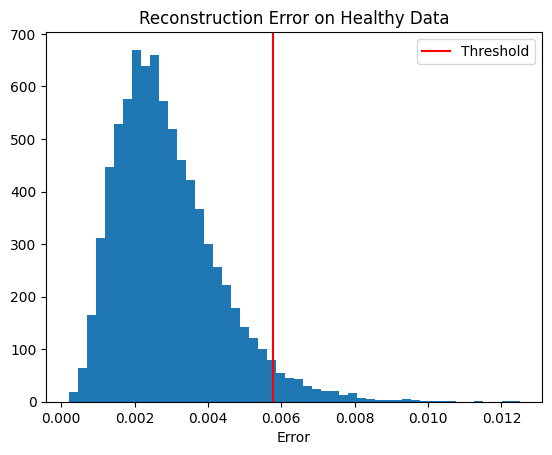

In [ ]:
# Get reconstruction error on healthy data
autoencoder_01.eval()
with torch.no_grad():
    healthy_rebuilt = autoencoder_01(healthy_t)
    healthy_errors = torch.mean((healthy_rebuilt - healthy_t)**2, dim=1).numpy()

# Set threshold = mean + 2 standard deviations
threshold = healthy_errors.mean() + 2 * healthy_errors.std()

print(f"Mean healthy error: {healthy_errors.mean():.6f}")
print(f"Threshold: {threshold:.6f}")

plt.hist(healthy_errors, bins=50)
plt.axvline(threshold, color='red', label='Threshold')
plt.title('Reconstruction Error on Healthy Data')
plt.xlabel('Error')
plt.legend()
plt.show()

Mean critical error: 0.025731
% flagged as anomaly: 92.0%


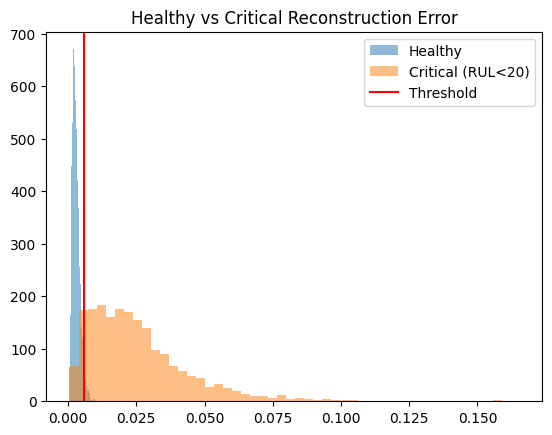

In [ ]:
# Take cycles right before engine failure (RUL < 20)
critical_df = df[df['RUL'] < 20]
critical_sensors = critical_df[sensor_cols].values
critical_t = torch.FloatTensor(critical_sensors)

with torch.no_grad():
    critical_rebuilt = autoencoder_01(critical_t)
    critical_errors = torch.mean((critical_rebuilt - critical_t)**2, dim=1).numpy()

print(f"Mean critical error: {critical_errors.mean():.6f}")
print(f"% flagged as anomaly: {(critical_errors > threshold).mean()*100:.1f}%")

plt.hist(healthy_errors, bins=50, alpha=0.5, label='Healthy')
plt.hist(critical_errors, bins=50, alpha=0.5, label='Critical (RUL<20)')
plt.axvline(threshold, color='red', label='Threshold')
plt.legend()
plt.title('Healthy vs Critical Reconstruction Error')
plt.show()

In [ ]:
torch.save(autoencoder_01.state_dict(), 'autoencoder_model.pth')
import joblib
joblib.dump(threshold, 'anomaly_threshold.pkl')
print("Autoencoder and threshold saved.")

Autoencoder and threshold saved.


USING THE ACTUAL TXT FILES FROM NASA DATASETS GIVEN TO TRAIN AND TEST

In [ ]:
# Load test data
test_df = pd.read_csv('/content/test_FD001.txt', sep=r'\s+', header=None, names=columns)

# Load true RUL answers
true_rul = pd.read_csv('/content/RUL_FD001.txt', sep=r'\s+', header=None, names=['RUL'])

# Drop the same constant sensors we dropped before
test_df.drop(columns=constant_sensors, inplace=True)

# Scale using the SAME scaler from training (never fit a new one on test data)
test_df[sensor_cols] = scaler.transform(test_df[sensor_cols])

print(test_df.shape)
print(true_rul.shape)

NameError: name 'scaler' is not defined

In [ ]:
print(scaler)

MinMaxScaler()


creating 30 cycles of each engine from the actual test dataset


In [ ]:
def get_last_window(test_df, sequence_length=30):
    X_test_final = []

    for engine_id in test_df['engine_id'].unique():
        engine_data = test_df[test_df['engine_id'] == engine_id][sensor_cols].values

        # If engine has fewer than 30 cycles, pad with the first row repeated
        if len(engine_data) < sequence_length:
            padding = np.repeat(engine_data[0:1], sequence_length - len(engine_data), axis=0)
            engine_data = np.vstack([padding, engine_data])

        # Take just the last 30 cycles
        last_window = engine_data[-sequence_length:]
        X_test_final.append(last_window)

    return np.array(X_test_final)

X_test_final = get_last_window(test_df)
print(X_test_final.shape)

(100, 30, 15)


In [ ]:
engine_6_window = X_test_final[0]  # index 4 = engine 5
print(engine_6_window.shape)
print(engine_6_window.tolist())

(30, 15)
[[0.15060240963856586, 0.37955090473076325, 0.2223160027008788, 1.0, 0.8051529790660226, 0.16666666666696983, 0.14668401687158195, 0.38690476190476275, 0.7398720682302695, 0.26470588235270043, 0.20476829394158358, 0.21315890727203168, 0.4166666666666714, 0.6821705426356601, 0.6868268434134208], [0.3765060240963862, 0.34663178548071016, 0.3222484807562438, 1.0, 0.6859903381642596, 0.22727272727297532, 0.15808130664991182, 0.38690476190476275, 0.6993603411513902, 0.2205882352941444, 0.15564041696769948, 0.4586379376683354, 0.4166666666666714, 0.7286821705426334, 0.7213476940071786], [0.37048192771086974, 0.28515369522563816, 0.4080013504388944, 1.0, 0.6795491143317349, 0.19696969696997257, 0.10571659337701078, 0.25595238095238315, 0.5735607675906209, 0.25, 0.17008979254824652, 0.2570219315121207, 0.25, 0.6666666666666643, 0.6621099143882887], [0.3915662650602485, 0.35208197078701176, 0.332039162727888, 1.0, 0.6940418679549083, 0.16666666666696983, 0.10239612312662416, 0.27380952

Official NASA test RMSE: 16.01 cycles


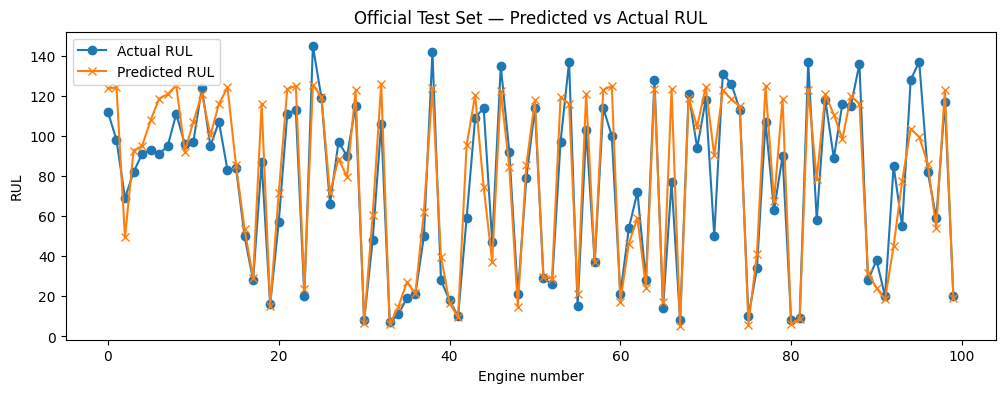

In [ ]:
model_03.eval()
X_test_final_t = torch.FloatTensor(X_test_final)

with torch.no_grad():
    final_predictions = model_03(X_test_final_t).squeeze().numpy()

# Compare against true RUL
true_rul_values = true_rul['RUL'].values

rmse_final = np.sqrt(np.mean((final_predictions - true_rul_values)**2))
print(f"Official NASA test RMSE: {rmse_final:.2f} cycles")

plt.figure(figsize=(12,4))
plt.plot(true_rul_values, label='Actual RUL', marker='o')
plt.plot(final_predictions, label='Predicted RUL', marker='x')
plt.legend()
plt.title('Official Test Set — Predicted vs Actual RUL')
plt.xlabel('Engine number')
plt.ylabel('RUL')
plt.show()

In [ ]:
from google.colab import files

files.download('rul_model.pth')
files.download('autoencoder_model.pth')

files.download('anomaly_threshold.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>